<a href="https://colab.research.google.com/github/pazylkhann/d2l.ai-learning-process/blob/main/Preliminaries/Probability_and_Statistics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install --no-deps d2l

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.7/111.7 kB 2.3 MB/s eta 0:00:00


##Probability and Statistics

In [ ]:
%matplotlib inline
import random
import torch
from torch.distributions.multinomial import Multinomial
from d2l import torch as d2l

In [ ]:
num_tosses = 100
heads = sum([random.random() > 0.5 for _ in range(num_tosses)])
tails = num_tosses - heads
print("heads, tails:", [heads, tails])

heads, tails: [55, 45]


In [ ]:
fair_probs = torch.tensor([0.5, 0.5])     # Generally, we can simulate multiple draws from any variable with a finite number of possible outcome
Multinomial(100, fair_probs).sample()     # Here we can see that Multinomial function works according to vector(fair_probs) with a .sample() by selecting
                                          # random number of outcomes' count

tensor([47., 53.])

In [ ]:
Multinomial(100, fair_probs).sample() / 100     # Calculating frequency of estimators for each outcome

tensor([0.4700, 0.5300])

In [ ]:
counts = Multinomial(10000, fair_probs).sample()   # evaluating fairness by setting draws with more tosses
counts / 10000

tensor([0.4942, 0.5058])

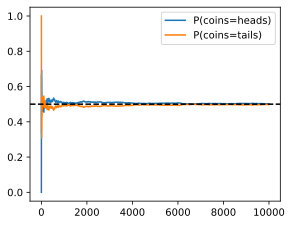

In [ ]:
# As sample size grow, errors should go down, so in this case,
# We will get more intuition how estimate evolves within 1-10000 sample size
counts = Multinomial(1, fair_probs).sample((10000, ))
cum_counts = counts.cumsum(dim=0)      # adds number of heads and tails cumulatively by keeping the shape of [heads, tails] growing row by row
estimates = cum_counts / cum_counts.sum(dim=1, keepdims=True)   # summarizes number of trials by each step so it can stay in dim=1 form and can divide cum_counts by it
estimates = estimates.numpy()

d2l.set_figsize((4.5, 3.5))
d2l.plt.plot(estimates[:, 0], label="P(coins=heads)")
d2l.plt.plot(estimates[:, 1], label="P(coins=tails)")
d2l.plt.axhline(y=0.5, color='black', linestyle='dashed')
d2l.plt.gca().set_label('Samples')
d2l.plt.gca().set_label('Estimated probability')
d2l.plt.legend()

In [ ]:
# Theory and learning material was done